# What Makes a Hit? Predicting BTS Track Popularity

**Objective:** Use Spotify audio features and supervised learning to predict the popularity of BTS tracks and understand which sonic characteristics are most associated with higher popularity scores.
​

**Deliverables:** Clean dataset of BTS tracks and audio features, regression models (baseline linear and tree‑based), model performance comparison, feature importance analysis, and interpretable insights on how musical attributes relate to Spotify popularity.

# Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

sns.set(style="whitegrid", context="talk")

# Data Loading & Initial Inspection

In [25]:
df = pd.read_csv("bts_song_features_224.csv")

print(df.shape)
df.head()

(224, 26)


,Unnamed: 0,album_id,album_title,album_rd,album_seq,track_id,track_name,track_popularity,danceability,energy,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,0,6egaEe9JaULuUCkihSnYlH,2 Cool 4 Skool,2013-06-12,1,1UlnDZ5ubsSX3xrXu063dZ,Intro: 2 Cool 4 Skool,51,0.894,0.835,...,0.179,0.532,94.871,audio_features,1UlnDZ5ubsSX3xrXu063dZ,spotify:track:1UlnDZ5ubsSX3xrXu063dZ,https://api.spotify.com/v1/tracks/1UlnDZ5ubsSX...,https://api.spotify.com/v1/audio-analysis/1Uln...,63787,4
1,1,6egaEe9JaULuUCkihSnYlH,2 Cool 4 Skool,2013-06-12,2,5pjHS3EpHurMyIpB2QBnEd,We Are Bulletproof Pt.2,65,0.753,0.950,...,0.134,0.868,144.020,audio_features,5pjHS3EpHurMyIpB2QBnEd,spotify:track:5pjHS3EpHurMyIpB2QBnEd,https://api.spotify.com/v1/tracks/5pjHS3EpHurM...,https://api.spotify.com/v1/audio-analysis/5pjH...,223933,4
2,2,6egaEe9JaULuUCkihSnYlH,2 Cool 4 Skool,2013-06-12,3,4Ut6UU8Yyihz1jCZWSCQpu,Skit: Circle Room Talk,44,0.598,0.356,...,0.913,0.817,121.045,audio_features,4Ut6UU8Yyihz1jCZWSCQpu,spotify:track:4Ut6UU8Yyihz1jCZWSCQpu,https://api.spotify.com/v1/tracks/4Ut6UU8Yyihz...,https://api.spotify.com/v1/audio-analysis/4Ut6...,131907,3
3,3,6egaEe9JaULuUCkihSnYlH,2 Cool 4 Skool,2013-06-12,4,089PFeXotzDLNQz9NCk6pF,No More Dream,66,0.438,0.864,...,0.431,0.594,167.898,audio_features,089PFeXotzDLNQz9NCk6pF,spotify:track:089PFeXotzDLNQz9NCk6pF,https://api.spotify.com/v1/tracks/089PFeXotzDL...,https://api.spotify.com/v1/audio-analysis/089P...,222067,4
4,4,6egaEe9JaULuUCkihSnYlH,2 Cool 4 Skool,2013-06-12,5,2QVXLAI2Io3tDmhFOSumr0,Interlude,51,0.914,0.276,...,0.392,0.854,125.897,audio_features,2QVXLAI2Io3tDmhFOSumr0,spotify:track:2QVXLAI2Io3tDmhFOSumr0,https://api.spotify.com/v1/tracks/2QVXLAI2Io3t...,https://api.spotify.com/v1/audio-analysis/2QVX...,52440,4


# Feature Understanding & Cleaning

In [26]:
# check for duplicates and missing values

df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        224 non-null    int64  
 1   album_id          224 non-null    object 
 2   album_title       224 non-null    object 
 3   album_rd          224 non-null    object 
 4   album_seq         224 non-null    int64  
 5   track_id          224 non-null    object 
 6   track_name        224 non-null    object 
 7   track_popularity  224 non-null    int64  
 8   danceability      224 non-null    float64
 9   energy            224 non-null    float64
 10  key               224 non-null    int64  
 11  loudness          224 non-null    float64
 12  mode              224 non-null    int64  
 13  speechiness       224 non-null    float64
 14  acousticness      224 non-null    float64
 15  instrumentalness  224 non-null    float64
 16  liveness          224 non-null    float64
 1

,0
Unnamed: 0,0
album_id,0
album_title,0
album_rd,0
album_seq,0
track_id,0
track_name,0
track_popularity,0
danceability,0
energy,0


In [27]:
# drop index-like and non-numeric modeling columns
cols_to_drop = [
    'Unnamed: 0',   # index column from CSV
    'album_id', 'album_title', 'track_id', 'track_name',
    'type', 'id', 'uri', 'track_href', 'analysis_url'
]

df = df.drop(columns=cols_to_drop)

# create numeric release_year from album_rd
df['release_year'] = pd.to_datetime(df['album_rd']).dt.year

# drop the original date column
df = df.drop(columns=['album_rd'])

df.head()

,album_seq,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,release_year
0,1,51,0.894,0.835,8,-6.249,1,0.245,0.1790,0.266000,0.179,0.532,94.871,63787,4,2013
1,2,65,0.753,0.950,8,-5.090,0,0.160,0.0104,0.000006,0.134,0.868,144.020,223933,4,2013
2,3,44,0.598,0.356,9,-18.009,1,0.802,0.9120,0.000000,0.913,0.817,121.045,131907,3,2013
3,4,66,0.438,0.864,2,-5.185,1,0.470,0.0118,0.000002,0.431,0.594,167.898,222067,4,2013
4,5,51,0.914,0.276,1,-13.392,0,0.319,0.4940,0.762000,0.392,0.854,125.897,52440,4,2013


In this step, I remove index-like and identifier columns (such as internal IDs, URLs, and text labels) that do not meaningfully affect prediction and could add unnecessary noise to the models. I also convert the album release date into a numeric release_year feature so that all remaining predictors are clean, interpretable, and ready to feed into the regression algorithms.

# Exploratory Data Analysis

### Distribution of Track Popularity

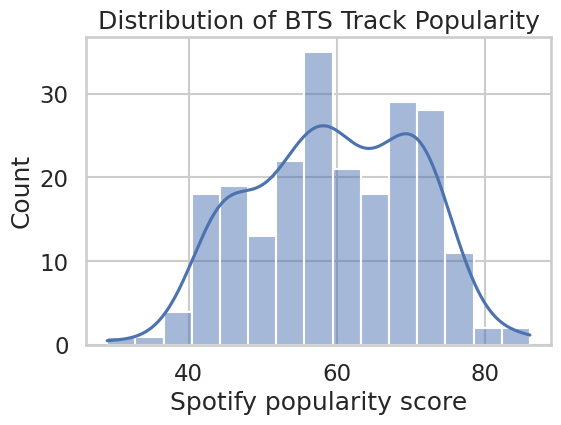

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(df['track_popularity'], bins=15, kde=True)

plt.title("Distribution of BTS Track Popularity")
plt.xlabel("Spotify popularity score")
plt.ylabel("Count")

plt.show()

### Pairwise Relatinoships with Key Audio Features

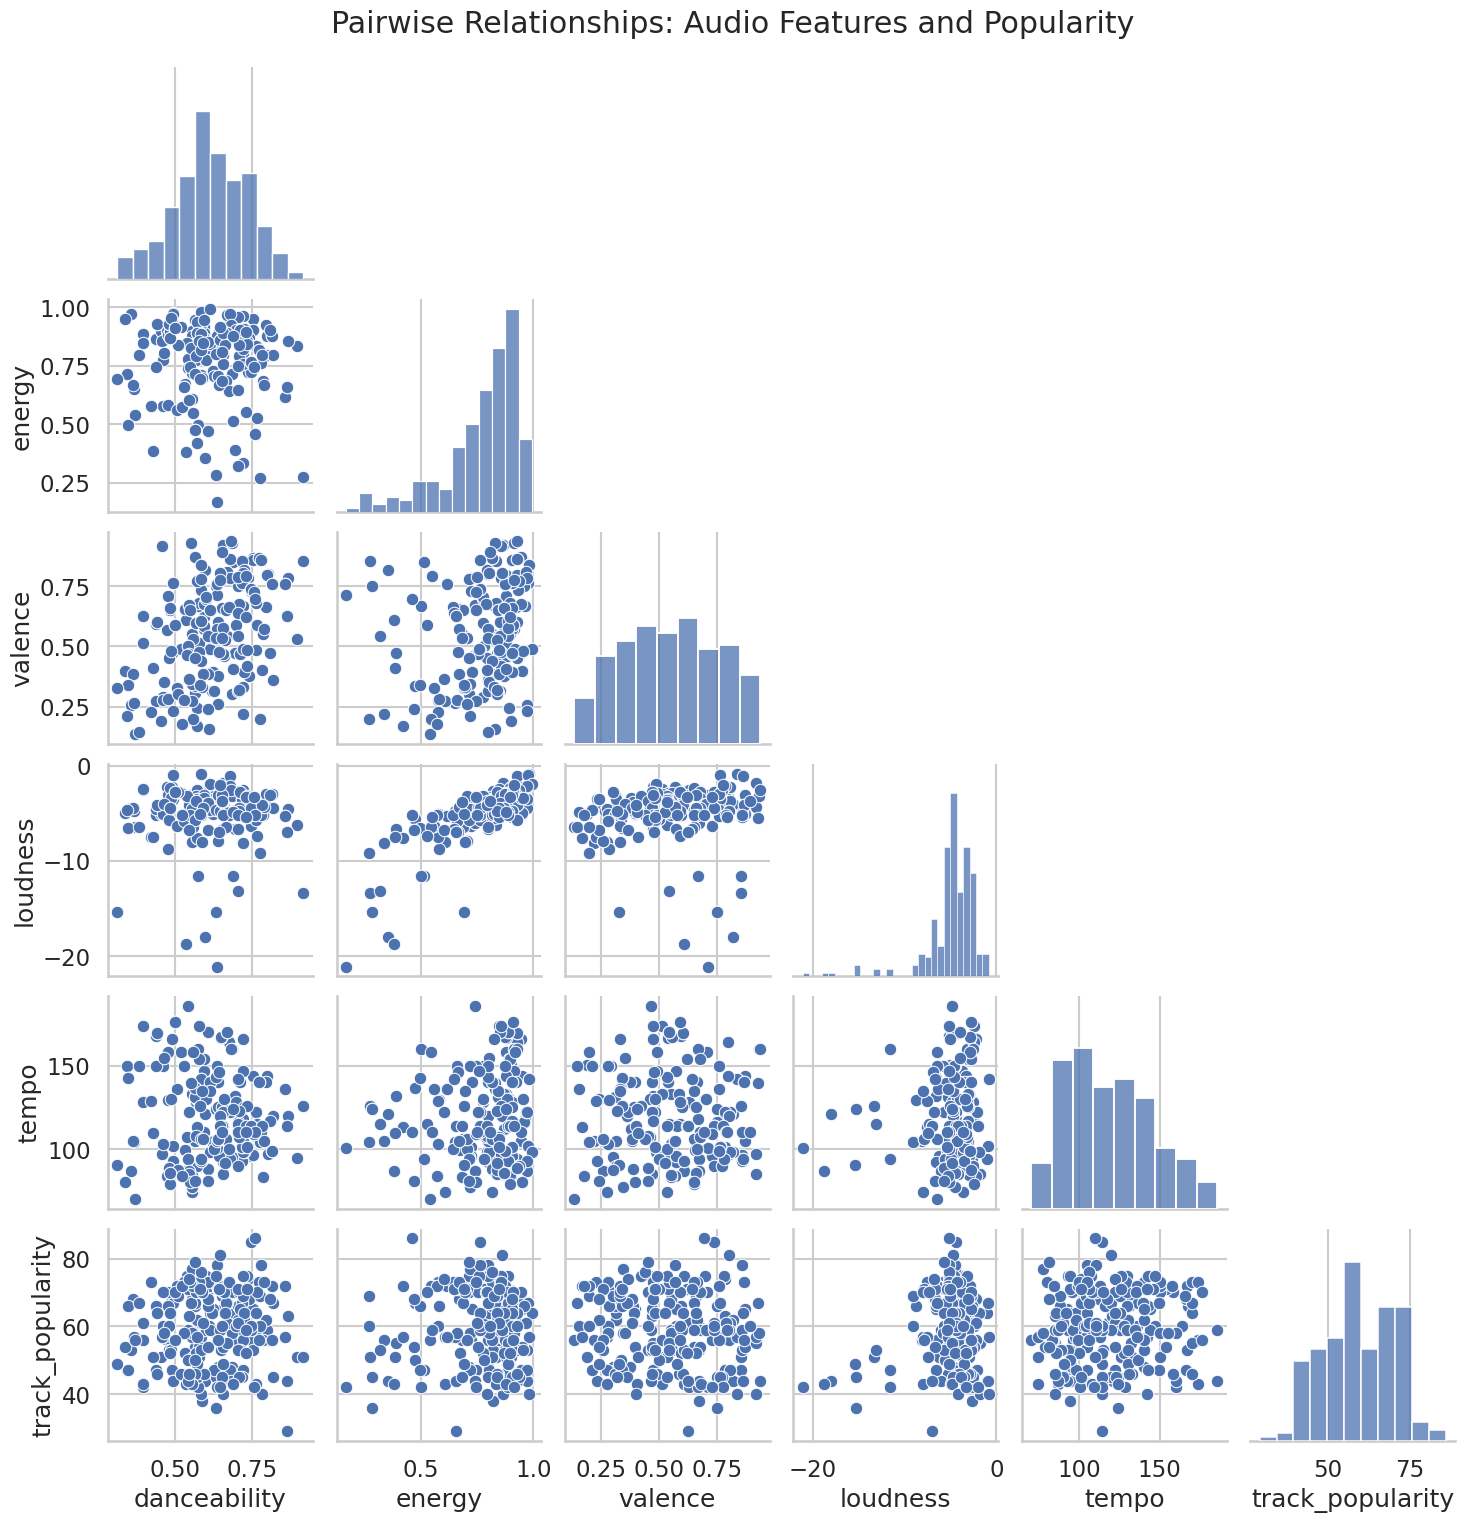

In [29]:
key_feats = ['danceability', 'energy', 'valence', 'loudness', 'tempo']

sns.pairplot(
    df[key_feats + ['track_popularity']],
    diag_kind='hist',
    corner=True
)
plt.suptitle("Pairwise Relationships: Audio Features and Popularity", y=1.02)
plt.show()

### Correlation Heatmap

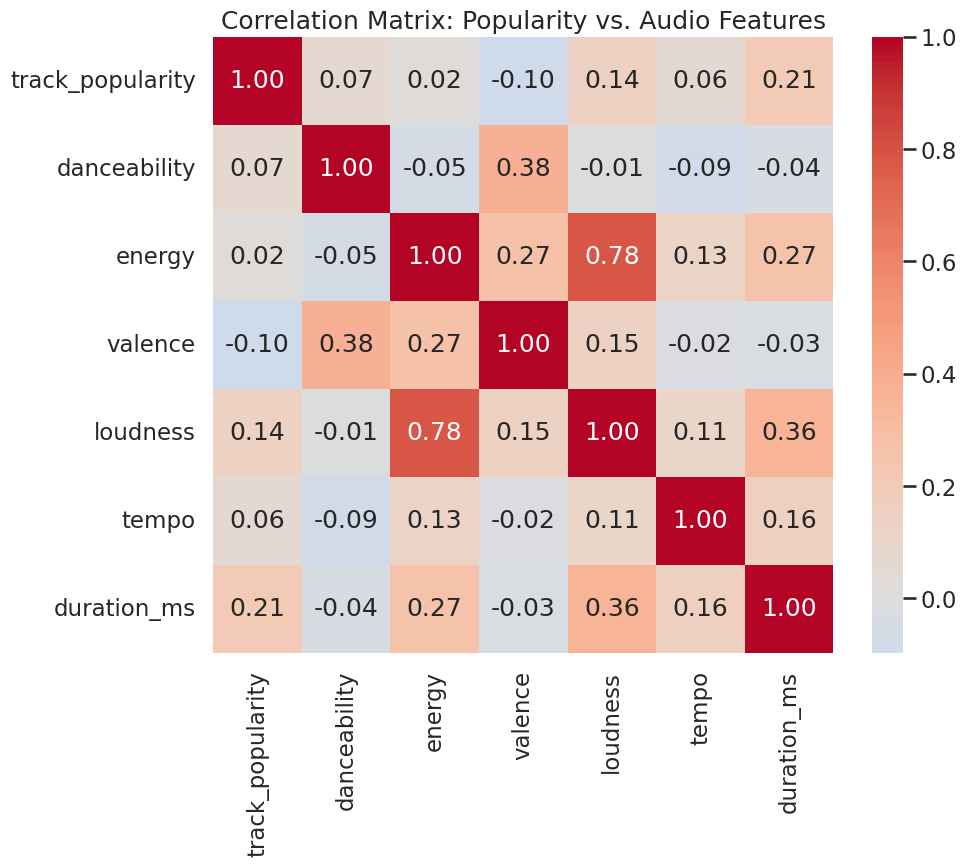

In [42]:
plt.figure(figsize=(10,8))
corr = df[['track_popularity'] + key_feats + ['duration_ms']].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix: Popularity vs. Audio Features")
plt.show()

The correlation matrix reveals a strong positive relationship between loudness and energy **(correlation > 0.7)**, which suggests potential multicollinearity between these two features. This is not unexpected, as louder tracks are typically perceived as more energetic. While this overlap does not pose a major issue for the predictive goal of the project, it does indicate that these features may carry partially redundant information. This relationship is important to note when interpreting model behavior and helps motivate the use of models that are less sensitive to multicollinearity or that rely on overall feature similarity rather than individual coefficient estimates.

### Popularity by Release Year

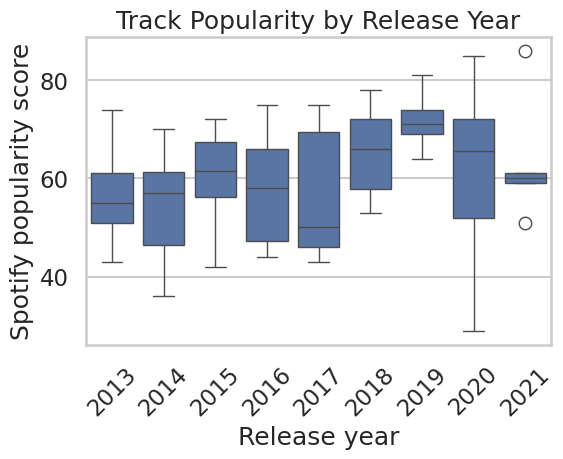

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='release_year', y='track_popularity', data=df)

plt.title("Track Popularity by Release Year")
plt.xlabel("Release year")
plt.ylabel("Spotify popularity score")
plt.xticks(rotation=45)

plt.show()

In this section, I explore how BTS track popularity is distributed and how it relates to core audio features such as danceability, energy, valence, loudness, tempo, and duration. Visualizing pairwise relationships, correlations, and trends over release year helps surface intuitive patterns in the data and informs which predictors are likely to be most useful for the supervised learning models.

# Modeling Setup (Train/Test Split)

In [32]:
# define feature columns and target
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'album_seq', 'release_year'
]

x = df[feature_cols]
y = df['track_popularity']

In [44]:
# 60% train, 40% (val + test)
xtrain, xother, ytrain, yother = train_test_split(
    x, y, test_size=0.4, random_state=42
)

# split the remaining 40% into 20% val, 20% test
xval, xtest, yval, ytest = train_test_split(
    xother, yother, test_size=0.5, random_state=42
)

len(xtrain), len(xval), len(xtest)

(134, 45, 45)

I split the data into three parts: 60% for training, 20% for validation, and 20% for final testing. The training set is used to fit the models, the validation set is used to compare and tune different algorithms, and the test set is kept aside until the end to provide an unbiased estimate of out‑of‑sample performance.

# Data Processing: Scaling

Because the Spotify audio features are measured on different scales (e.g., duration in milliseconds versus normalized features such as danceability and energy), feature scaling is required for models that rely on coefficient magnitudes.

Features are standardized using z-score normalization (zero mean, unit variance) prior to fitting linear models, allowing coefficients to be compared directly. Tree-based models are trained on the original feature scales, as they are invariant to feature scaling.

In [34]:
xtrain_scaled = scaler.fit_transform(xtrain)
xval_scaled   = scaler.transform(xval)
xtest_scaled  = scaler.transform(xtest)

# Baseline Regression: Linear Model

As a starting point, a multiple linear regression predicts track popularity from core Spotify audio features (danceability, energy, loudness, valence, tempo, and duration). This baseline establishes how much variance in BTS track popularity can be explained by a simple linear model before trying tree‑based methods.

In [35]:
lm = LinearRegression().fit(xtrain_scaled, ytrain)

ypred = lm.predict(xval_scaled)
lm_rmse_val = mean_squared_error(yval,ypred)**(1/2)

lm_rmse_val

13.015651608090034

# Improved Models

In [36]:
rf = RandomForestRegressor()
model_rf = rf.fit(xtrain, ytrain)

ypred = model_rf.predict(xval)
rf_rmse_val = mean_squared_error(yval, ypred)**(1/2)

rf_rmse_val

13.385523717831038

In [37]:
gb = GradientBoostingRegressor()
model_gb = gb.fit(xtrain, ytrain)

ypred = model_gb.predict(xval)
gb_rmse_val = mean_squared_error(yval, ypred)**(1/2)

gb_rmse_val

13.78635808726511

In [38]:
knn = KNeighborsRegressor(n_neighbors=5)
model_knn = knn.fit(xtrain_scaled, ytrain)

ypred = model_knn.predict(xval_scaled)
knn_rmse_val = mean_squared_error(yval, ypred)**(1/2)

knn_rmse_val

12.865423083253466

After proper feature scaling, the k-nearest neighbors model achieved the lowest validation RMSE.

Linear and tree-based models performed comparably, indicating that multiple modeling approaches extract overlapping but distinct signals from Spotify audio features.

# Model Evaluation & Error Analysis

Across all models, the k-nearest neighbors model achieved the lowest validation RMSE, so it remains the main model for the analysis.

The RMSE of approximately 13 popularity points suggests that the model captures meaningful variation in track popularity, while still missing a non-trivial amount of variance. This level of error is expected, as popularity is influenced by factors not captured in audio features alone, such as marketing, release timing, and fan engagement dynamics.

While some overlap between features exists, distance-based modeling appears relatively robust to this redundancy when features are properly scaled. As a result, correlated features do not present a major limitation for prediction in this setting, though they may still contribute to residual error and reduced interpretability.

# Interpreting Feature Importance (What Drives Popularity?)

In [39]:
# linear regression coefficients (main feature importance)
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lm.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
8,tempo,0.733198
11,release_year,0.702729
10,album_seq,0.565221
9,duration_ms,0.460520
0,danceability,0.233726
7,valence,-0.403299
6,liveness,-1.022837
2,loudness,-1.494805
3,speechiness,-1.961983
1,energy,-2.107100


Because of correlated features like loudness and energy, coefficient magnitudes should be interpreted cautiously. The directionality is more informative than the exact values.

In [40]:
# random forest feature importances
arr_feat = model_rf.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": arr_feat
}).sort_values("importance", ascending=False)

feat_imp

,feature,importance
3,speechiness,0.175553
2,loudness,0.131553
9,duration_ms,0.116090
11,release_year,0.094893
10,album_seq,0.076281
8,tempo,0.069610
4,acousticness,0.066726
7,valence,0.065533
1,energy,0.064620
6,liveness,0.061709


Random forest feature importances offer a non-linear view of which audio features contribute most to prediction accuracy. Unlike linear regression, these scores reflect relative influence rather than the direction of an effect. Features such as speechiness, loudness, and duration emerge as particularly important, suggesting that both vocal characteristics and track structure play a role in popularity. Because correlated features tend to share importance in this framework, random forest is less sensitive to multicollinearity and is useful for identifying broadly influential features.

# Findings & Interpretation



### Key Findings

**1. Popularity is driven by a combination of features rather than any single audio characteristic.**
Both linear regression and random forest indicate that no individual feature dominates prediction, suggesting that BTS track popularity reflects interactions across multiple audio and contextual attributes.

**2. Structural and temporal features show consistent relationships with popularity.**
Linear regression results suggest that faster tempo, longer duration, more recent release year, and later album placement are generally associated with higher popularity scores within this dataset.

**3. Highly acoustic or instrumental tracks tend to be less popular.**
Directionality from the linear model shows negative associations for acousticness and instrumentalness, which aligns with the vocal-driven nature of BTS’s most successful releases.

**4. Vocal presence and track structure emerge as influential across models.**
Random forest feature importances highlight speechiness, loudness, duration, and release year as key contributors to predictive accuracy, indicating that both vocal characteristics and song structure matter for popularity.

**5. Correlated features affect interpretation but not overall predictive insight.**
Features such as loudness and energy exhibit overlap, making individual coefficients less stable, but this redundancy does not undermine the broader conclusions. Instead, it reinforces the idea that popularity depends on combined feature patterns, which helps explain the strong performance of a neighborhood-based model like KNN.

**6. KNN provides a reasonable relative prediction of track popularity.**
After feature scaling, the k-nearest neighbors model achieved the lowest validation RMSE (approximately 12), indicating that predicted popularity scores are typically within about 12 points of actual values on the 0-100 scale. While this level of accuracy is insufficient for precise forecasting, it is meaningful for relative comparison between tracks and supports the idea that songs with similar audio profiles tend to achieve similar popularity outcomes.


### Interpreting the Findings in the Context of BTS’s Musical Journey

**1. Rap elements are most effective when balanced within BTS’s broader pop sound.**
The prominence of features related to rap and spoken delivery reflects how foundational rap has been to BTS’s identity since debut. However, the results suggest that tracks where rap sections are integrated into melodic, pop-oriented structures tend to perform better than those dominated by spoken delivery, highlighting the importance of balance in BTS’s most successful releases.

**2. Production intensity reflects BTS’s transition to a global stage.**
As BTS’s audience expanded internationally, their music shifted toward more polished and high-energy production. The importance of production-related features aligns with this transition, reflecting a move toward arena-ready tracks designed for large-scale performances and global streaming audiences.

**3. Song length and release timing mirror BTS’s artistic and commercial growth.**
Later releases and slightly longer tracks tend to align with higher popularity, which is consistent with BTS’s evolution into a concept-driven, album-focused group. This shift coincides with a period in which their music became more expansive and their global presence more pronounced.

**4. Acoustic and instrumental tracks play a more niche role within BTS’s catalog.**
While these tracks are artistically meaningful and often serve narrative or thematic purposes within albums, they appear less central to BTS’s commercial success compared to vocally driven songs that emphasize performance and group identity.

**5. BTS’s success comes from stylistic evolution rather than a fixed formula.**
Taken together, the findings suggest that BTS’s popularity is driven by their ability to adapt musically over time while maintaining recognizable patterns. Tracks that combine rap presence, strong vocal sections, polished production, and clear structure tend to align with the most popular phases of their career.

# Limitations & Next Steps

### Limitations

The dataset is relatively small (224 tracks) and focused exclusively on BTS, so the observed patterns may not generalize to other artists, genres, or time periods. In addition, the analysis relies on Spotify audio features and limited metadata, excluding important commercial and social drivers of popularity such as marketing intensity, playlist placement, fanbase growth, and viral exposure. As a result, the models are better suited for understanding relative popularity patterns within this context rather than producing precise or broadly generalizable predictions.

### Next Steps

Future work could expand this analysis to a larger, multi-artist dataset to test whether the observed patterns generalize beyond BTS. Incorporating additional contextual features such as playlist placement, release timing, or simple lyric metrics would help capture non-audio drivers of popularity. From a modeling perspective, more systematic hyperparameter tuning and a complementary "hit" vs. non-hit classification setup could provide further insight into what differentiates highly successful tracks.